In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import cv2
import pydot

2025-01-25 09:02:27.810094: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737775047.871539   45004 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737775047.889579   45004 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-25 09:02:28.025733: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
base_path = "/home/pujan/Hackathon3.0/ml/pujan/Data/asl_alphabet_train"


In [3]:
#load_dataset function to load the data and resize the images to 50x50
def load_dataset(directory):
  images = []
  labels = []
  for idx, label in enumerate(uniq_labels):
    for file in os.listdir(directory + '/'+label):
      filepath = directory +'/'+ label + "/" + file
      img = cv2.resize(cv2.imread(filepath),(50,50))
      images.append(img)
      labels.append(idx)
  images = np.asarray(images)
  labels = np.asarray(labels)
  return images, labels

In [4]:
#display_images function to show examples
def display_images(x_data,y_data, title, display_label = True):
    x, y = x_data,y_data
    fig, axes = plt.subplots(5, 8, figsize = (18, 5))
    fig.subplots_adjust(hspace = 0.5, wspace = 0.5)
    fig.suptitle(title, fontsize = 18)
    for i, ax in enumerate(axes.flat):
        ax.imshow(cv2.cvtColor(x[i], cv2.COLOR_BGR2RGB))
        if display_label:
            ax.set_xlabel(uniq_labels[y[i]])
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()

In [5]:
#loading_dataset into X_pre and Y_pre
data_dir = base_path
uniq_labels = sorted(os.listdir(data_dir))
X_pre, Y_pre = load_dataset(data_dir)
print(X_pre.shape, Y_pre.shape)

(78000, 50, 50, 3) (78000,)


In [6]:
#spliting dataset into 80% train, 10% validation and 10% test data
X_train, X_test, Y_train, Y_test = train_test_split(X_pre, Y_pre, train_size = 0.8)
X_test, X_eval, Y_test, Y_eval = train_test_split(X_test, Y_test, test_size = 0.5)

Train images shape (62400, 50, 50, 3) (62400,)
Test images shape (7800, 50, 50, 3) (7800,)
Evaluate image shape (7800, 50, 50, 3) (7800,)
Printing the labels ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'] 26


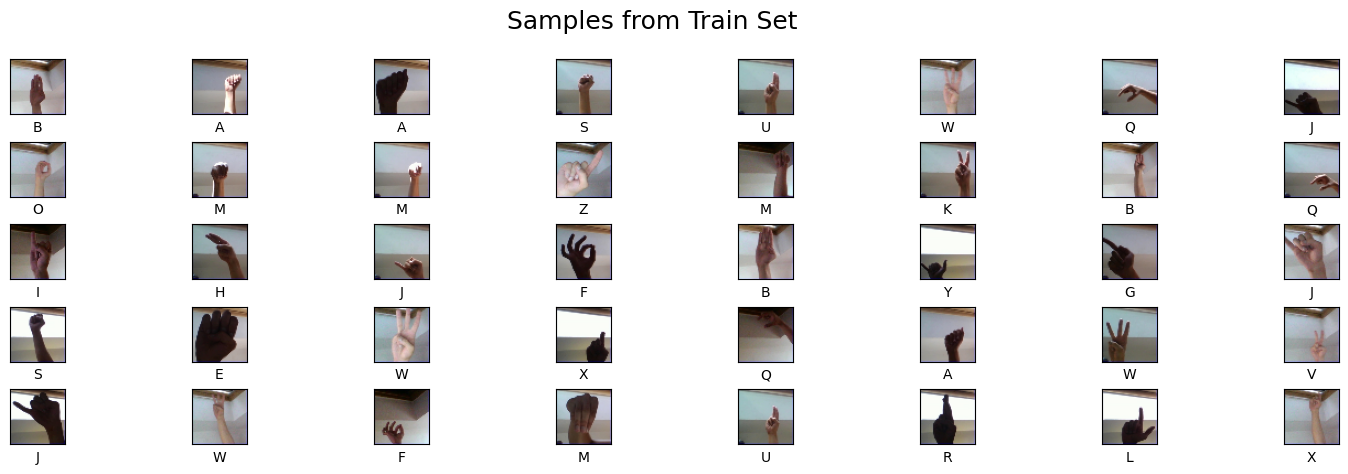

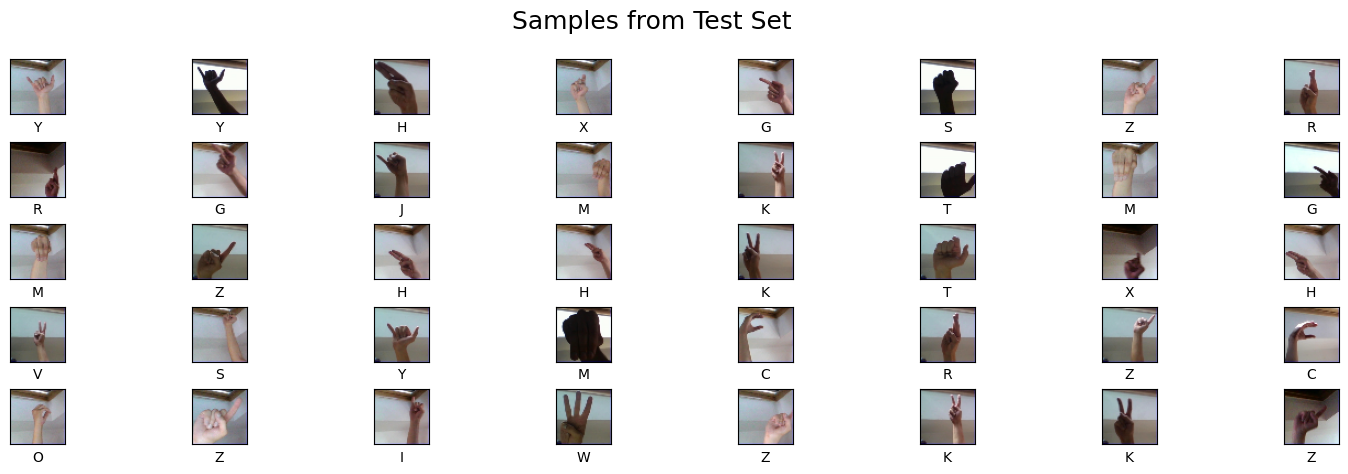

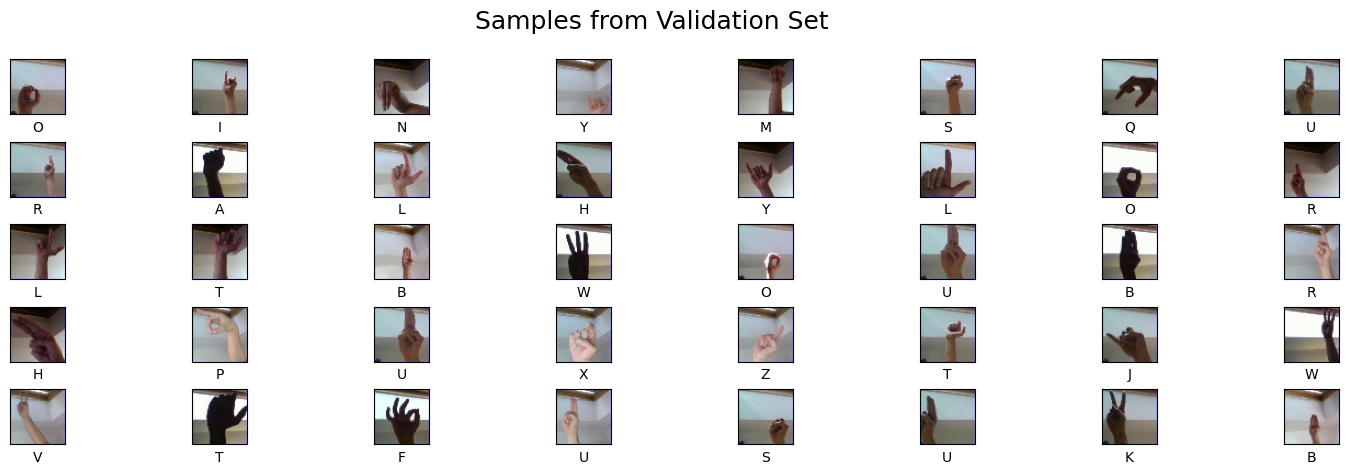

In [7]:
#print shapes and show examples for each set
print("Train images shape",X_train.shape, Y_train.shape)
print("Test images shape",X_test.shape, Y_test.shape)
print("Evaluate image shape",X_eval.shape, Y_eval.shape)
print("Printing the labels",uniq_labels, len(uniq_labels))
display_images(X_train,Y_train,'Samples from Train Set')
display_images(X_test,Y_test,'Samples from Test Set')
display_images(X_eval,Y_eval,'Samples from Validation Set')

In [8]:
# converting Y_tes and Y_train to One hot vectors using to_categorical
# example of one hot => '1' is represented as [0. 1. 0. . . . . 0.]
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)
Y_eval = to_categorical(Y_eval)
X_train = X_train / 255.
X_test = X_test/ 255.
X_eval = X_eval/ 255.

In [9]:
# Building an improved model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(50, 50, 3)),
    tf.keras.layers.BatchNormalization(),  # Added Batch Normalization
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2, 2)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),  # Increased dense layer size
    tf.keras.layers.Dropout(0.5),  # Added Dropout for regularization
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(26, activation='softmax')  # Output layer for 26 classes
])

model.summary()

/home/pujan/Hackathon3.0/env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-01-25 09:03:09.226576: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 46, 46, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 21, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 163,050 (636.91 KB)

 Trainable params: 162,474 (634.66 KB)

 Non-trainable params: 576 (2.25 KB)

In [10]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Callbacks for optimization
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,  # Increased patience for longer training
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce learning rate by 50% if no improvement
    patience=5,
    min_lr=1e-6
)

model_checkpoint = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)


In [11]:
# Compile the model with a categorical loss function
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
#  Data Augmentation for better generalization
datagen = ImageDataGenerator(
    rotation_range=5,  # Rotate images up to 10 degrees
    width_shift_range=0.05,  # Shift images horizontally by 10%
    height_shift_range=0.05,  # Shift images vertically by 10%
    shear_range=0.05,  # Shear transformation
    zoom_range=0.05,  # Random zoom
    horizontal_flip=False,  # Disable horizontal flip for sign detection
    fill_mode='nearest'  # Fill missing pixels
)


In [13]:
# Train the model
batch_size = 8  # Adjust batch size based on memory availability

train_generator = datagen.flow(X_train, Y_train, batch_size=batch_size)
eval_datagen = ImageDataGenerator()  # No augmentation for evaluation
eval_generator = eval_datagen.flow(X_eval, Y_eval, batch_size=batch_size)
history = model.fit(
    train_generator,
    epochs=15,  # Adjust epochs based on overfitting
    validation_data=eval_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

/home/pujan/Hackathon3.0/env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
   4/7800 ━━━━━━━━━━━━━━━━━━━━ 5:19 41ms/step - accuracy: 0.1068 - loss: 3.9569 

2025-01-25 09:03:38.816137: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 26615808 exceeds 10% of free system memory.
2025-01-25 09:03:38.816987: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 26615808 exceeds 10% of free system memory.
2025-01-25 09:03:38.819065: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 24385536 exceeds 10% of free system memory.
2025-01-25 09:03:38.819113: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 24385536 exceeds 10% of free system memory.
2025-01-25 09:03:38.821998: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29251584 exceeds 10% of free system memory.


7800/7800 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1906 - loss: 2.7088

7800/7800 ━━━━━━━━━━━━━━━━━━━━ 213s 27ms/step - accuracy: 0.1907 - loss: 2.7087 - val_accuracy: 0.6559 - val_loss: 0.9532 - learning_rate: 0.0010
Epoch 2/15
7798/7800 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6393 - loss: 1.0492

...

7800/7800 ━━━━━━━━━━━━━━━━━━━━ 209s 27ms/step - accuracy: 0.8216 - loss: 0.5439 - val_accuracy: 0.9197 - val_loss: 0.2200 - learning_rate: 0.0010
Epoch 5/15
7798/7800 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8574 - loss: 0.4415

7800/7800 ━━━━━━━━━━━━━━━━━━━━ 208s 27ms/step - accuracy: 0.8574 - loss: 0.4415 - val_accuracy: 0.9241 - val_loss: 0.2060 - learning_rate: 0.0010
Epoch 6/15
7800/7800 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8771 - loss: 0.3861

7800/7800 ━━━━━━━━━━━━━━━━━━━━ 211s 27ms/step - accuracy: 0.8771 - loss: 0.3861 - val_accuracy: 0.9579 - val_loss: 0.1150 - learning_rate: 0.0010
Epoch 7/15
7800/7800 ━━━━━━━━━━━━━━━━━━━━ 210s 27ms/step - accuracy: 0.8905 - loss: 0.3474 - val_accuracy: 0.9615 - val_loss: 0.1163 - learning_rate: 0.0010
Epoch 8/15
7800/7800 ━━━━━━━━━━━━━━━━━━━━ 211s 27ms/step - accuracy: 0.9024 - loss: 0.3239 - val_accuracy: 0.9215 - val_loss: 0.2172 - learning_rate: 0.0010
Epoch 9/15
7799/7800 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9148 - loss: 0.2844

7800/7800 ━━━━━━━━━━━━━━━━━━━━ 207s 27ms/step - accuracy: 0.9148 - loss: 0.2844 - val_accuracy: 0.9735 - val_loss: 0.0762 - learning_rate: 0.0010
Epoch 10/15
7799/7800 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9200 - loss: 0.2584

7800/7800 ━━━━━━━━━━━━━━━━━━━━ 201s 26ms/step - accuracy: 0.9200 - loss: 0.2584 - val_accuracy: 0.9751 - val_loss: 0.0744 - learning_rate: 0.0010
Epoch 11/15
7800/7800 ━━━━━━━━━━━━━━━━━━━━ 206s 26ms/step - accuracy: 0.9244 - loss: 0.2424 - val_accuracy: 0.9753 - val_loss: 0.0753 - learning_rate: 0.0010
Epoch 12/15
7800/7800 ━━━━━━━━━━━━━━━━━━━━ 208s 27ms/step - accuracy: 0.9313 - loss: 0.2274 - val_accuracy: 0.9726 - val_loss: 0.0812 - learning_rate: 0.0010
Epoch 13/15
7800/7800 ━━━━━━━━━━━━━━━━━━━━ 201s 26ms/step - accuracy: 0.9355 - loss: 0.2163 - val_accuracy: 0.9736 - val_loss: 0.0799 - learning_rate: 0.0010


In [14]:

# Save the final model
model.save('final_model.h5')

# Evaluate the model
eval_results = model.evaluate(X_eval, Y_eval, verbose=1)
print(f"Validation Accuracy: {eval_results[1] * 100:.2f}%")

244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9757 - loss: 0.0747
Validation Accuracy: 97.51%
